In [2]:
import cv2
import os
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from IPython.display import display, Image as IPImage

import torch
from torchvision.ops import nms

from utils import YOLOv11, apply_nms, box_iou_numpy, compute_map, compute_ap
from dataset import PolyDataset, collate_fn

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device : {DEVICE}')

CHECKPOINT   = 'checkpoints_1/train/best.pt'    # trained weights
SAVE_DIR     = Path('checkpoints_1/inference')

MODEL_NAME   = 'yolo11n'               # must match what you trained
NC           = 1
IMG_SIZE     = 640
CLASS_NAMES  = ['polyp']

CONF_THRESH  = 0.25                    # minimum confidence to show a box
IOU_THRESH   = 0.45                    # NMS IoU threshold

# BOX_COLOR    = (0, 255, 128)           # BGR green
# TEXT_COLOR   = (0, 0, 0)              # black text

BOX_COLOR    = (0, 0, 255)        # BGR → Red
TEXT_COLOR   = (0, 0, 0)        # BGR → Black


BOX_THICK    = 2
FONT         = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE   = 0.55
FONT_THICK   = 1

SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f'results will be saved to: {SAVE_DIR.resolve()}')

device : cpu
results will be saved to: C:\Users\blbon\Desktop\Projects\polyp_detection\checkpoints_1\inference


In [3]:
# load model
model = YOLOv11(model_name=MODEL_NAME, nc=NC)
ckpt  = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval()

print(f'Model loaded from {CHECKPOINT}')
print(f'Trained for {ckpt.get("epoch", "?")} epochs  |  '
      f'best_map50 = {ckpt.get("best_map50", "?")}')

Model loaded from checkpoints_1/train/best.pt
Trained for 77 epochs  |  best_map50 = 0.9671123827853805


In [4]:
#  preprocessing and postprocessing 

def letterbox_frame(frame, target=IMG_SIZE, color=(114, 114, 114)):
    
    H, W = frame.shape[:2]
    r = min(target / H, target / W)
    nW, nH = int(round(W * r)), int(round(H * r))
    resized = cv2.resize(frame, (nW, nH), interpolation=cv2.INTER_LINEAR)

    pad_w = target - nW
    pad_h = target - nH
    left = pad_w // 2
    top  = pad_h // 2

    padded = cv2.copyMakeBorder(
        resized, top, pad_h - top, left, pad_w - left,
        cv2.BORDER_CONSTANT, value=color
    )
    return padded, (r, left, top)


def preprocess(frame):
   
    padded, lb_params = letterbox_frame(frame)
    rgb = cv2.cvtColor(padded, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(
        rgb.astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    return t, lb_params


def postprocess(output, lb_params, orig_shape,
                conf_thresh=CONF_THRESH, iou_thresh=IOU_THRESH):
    
    r, pad_left, pad_top = lb_params
    orig_H, orig_W = orig_shape

    # reuse apply_nms from utils.py — expects [B, 8400, 5]
    output_permuted = output.permute(0, 2, 1)
    batch_preds = apply_nms(output_permuted,
                            conf_thresh=conf_thresh,
                            iou_thresh=iou_thresh)

    pred = batch_preds[0]  # single image: [N, 6] or empty
    if pred.shape[0] == 0:
        return []

    detections = []
    for bx1, by1, bx2, by2, sc, _ in pred:
        # remove letterbox padding and unscale to original coords
        ox1 = int(np.clip((bx1 - pad_left) / r, 0, orig_W))
        oy1 = int(np.clip((by1 - pad_top)  / r, 0, orig_H))
        ox2 = int(np.clip((bx2 - pad_left) / r, 0, orig_W))
        oy2 = int(np.clip((by2 - pad_top)  / r, 0, orig_H))
        detections.append({
            'x1': ox1, 'y1': oy1,
            'x2': ox2, 'y2': oy2,
            'score': float(sc),
            'label': CLASS_NAMES[0],
        })
    return detections


def draw_detections(frame, detections):
   
    out = frame.copy()
    for det in detections:
        x1, y1, x2, y2 = det['x1'], det['y1'], det['x2'], det['y2']
        score = det['score']
        label = det['label']

        cv2.rectangle(out, (x1, y1), (x2, y2), BOX_COLOR, BOX_THICK)

        text = f'{label} {score:.2f}'
        (tw, th), baseline = cv2.getTextSize(text, FONT, FONT_SCALE, FONT_THICK)
        label_y = max(y1 - 4, th + 4)
        cv2.rectangle(
            out,
            (x1, label_y - th - baseline - 2),
            (x1 + tw + 2, label_y + 2),
            BOX_COLOR, -1
        )
        cv2.putText(
            out, text, (x1 + 1, label_y - baseline),
            FONT, FONT_SCALE, TEXT_COLOR, FONT_THICK, cv2.LINE_AA
        )
    return out


print('Helpers ready.')


Helpers ready.


Image: c:\Users\blbon\Desktop\Projects\polyp_detection\dataset\test\images\Horizontal-CVC-557_png.rf.54f642eb47c7918a41d01c979e0d77ca.jpg  size=384x288
Inference time : 217.6 ms
Detections     : 2
  [0] polyp  conf=0.936  box=(125,94,169,137)
  [1] polyp  conf=0.926  box=(231,134,321,202)
Saved: checkpoints_1\inference\Horizontal-CVC-557_png.rf.54f642eb47c7918a41d01c979e0d77ca_pred.jpg


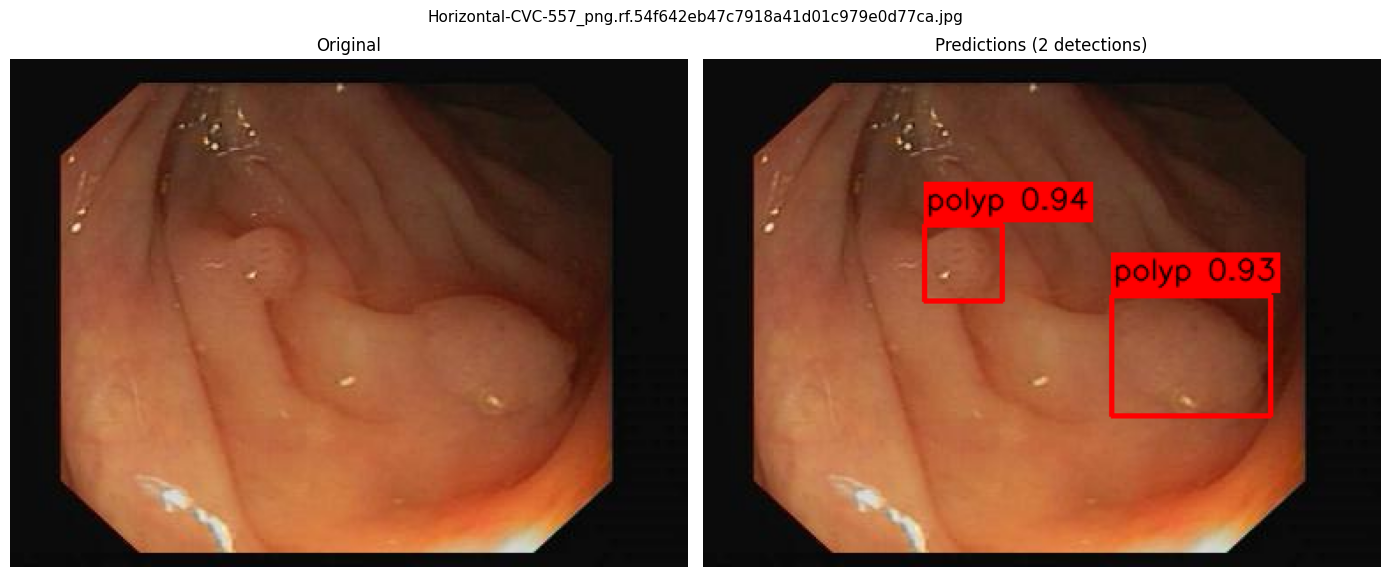

In [5]:
SCRIPT_DIR = os.getcwd()
IMAGE_PATH = os.path.join(SCRIPT_DIR, "dataset", "test", "images",
                              "Horizontal-CVC-557_png.rf.54f642eb47c7918a41d01c979e0d77ca.jpg")
frame = cv2.imread(IMAGE_PATH)
if frame is None:
    raise FileNotFoundError(f'Could not read: {IMAGE_PATH}')

orig_H, orig_W = frame.shape[:2]
print(f'Image: {IMAGE_PATH}  size={orig_W}x{orig_H}')


tensor, lb_params = preprocess(frame)

t0 = time.perf_counter()
with torch.no_grad():
    output = model(tensor)                
ms = (time.perf_counter() - t0) * 1000

detections = postprocess(output, lb_params, (orig_H, orig_W))

print(f'Inference time : {ms:.1f} ms')
print(f'Detections     : {len(detections)}')
for i, d in enumerate(detections):
    print(f'  [{i}] {d["label"]}  conf={d["score"]:.3f}  '
          f'box=({d["x1"]},{d["y1"]},{d["x2"]},{d["y2"]})')

#  draw & save 
annotated = draw_detections(frame, detections)

out_name  = Path(IMAGE_PATH).stem + '_pred.jpg'
out_path  = SAVE_DIR / out_name
cv2.imwrite(str(out_path), annotated)
print(f'Saved: {out_path}')

# display in notebook 
rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')
axes[1].imshow(rgb)
axes[1].set_title(f'Predictions ({len(detections)} detections)', fontsize=12)
axes[1].axis('off')
plt.suptitle(Path(IMAGE_PATH).name, fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / (Path(IMAGE_PATH).stem + '_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── VIDEO INFERENCE CELL ──────────────────────────

# 1. Setup paths
# Set your video name here (supports .mp4, .avi, .mov, etc.)
VIDEO_NAME = "demo_video.mp4" 
SCRIPT_DIR = os.getcwd()
VIDEO_PATH = os.path.join(SCRIPT_DIR, "dataset", "test", "video", VIDEO_NAME)

# 2. Open Video Source
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Could not open/find video: {VIDEO_PATH}")

# 3. Extract Metadata
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_in       = cap.get(cv2.CAP_PROP_FPS)
W_in         = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_in         = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Fallback for FPS if metadata is missing
if fps_in <= 0: fps_in = 30.0 

print(f"Processing: {Path(VIDEO_PATH).name}")
print(f"Resolution: {W_in}x{H_in} @ {fps_in:.2f} FPS | Total Frames: {total_frames}")

# 4. Setup Output Writer
# We force .mp4 output for maximum compatibility
out_video_path = SAVE_DIR / (Path(VIDEO_PATH).stem + "_inference.mp4")
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # High compatibility codec
writer = cv2.VideoWriter(
    str(out_video_path), 
    fourcc, 
    fps_in, 
    (W_in, H_in)
)

# 5. Inference Loop
frame_idx      = 0
total_dets     = 0
timing_history = []
preview_frames = [] # To show a strip in the notebook later
preview_every  = max(1, total_frames // 8)

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # --- PREPROCESS ---
        tensor, lb_params = preprocess(frame)
        
        # --- MODEL INFERENCE ---
        t0 = time.perf_counter()
        with torch.no_grad():
            output = model(tensor)
        ms_elapsed = (time.perf_counter() - t0) * 1000
        timing_history.append(ms_elapsed)

        # --- POSTPROCESS ---
        # Map boxes back to original video resolution (H_in, W_in)
        detections = postprocess(output, lb_params, (H_in, W_in))
        total_dets += len(detections)
        
        # --- VISUALIZATION ---
        annotated = draw_detections(frame, detections)
        
        # Add frame status stamp (Top-left corner)
        status_text = f"Frame {frame_idx} | Dets: {len(detections)}"
        cv2.putText(
            annotated, status_text, (15, 35), 
            FONT, 0.8, (255, 255, 255), 2, cv2.LINE_AA
        )

        # Write frame to output file
        writer.write(annotated)

        # Sample frames for notebook preview strip
        if frame_idx % preview_every == 0 and len(preview_frames) < 8:
            preview_frames.append((frame_idx, annotated.copy()))

        frame_idx += 1
        if frame_idx % 25 == 0:
            print(f"  Processed {frame_idx}/{total_frames} frames... ({ms_elapsed:.1f}ms/f)", end='\r')

finally:
    # 6. Cleanup Resources
    cap.release()
    writer.release()

print(f"\n\nInference Complete!")
print(f"» Total frames processed: {frame_idx}")
print(f"» Average speed: {np.mean(timing_history):.1f} ms/frame ({1000/np.mean(timing_history):.1f} FPS)")
print(f"» Output saved to: {out_video_path}")

# 7. Notebook Preview (Sampler Strip)
if len(preview_frames) > 0:
    n = len(preview_frames)
    cols = 4
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).flatten()
    
    for i, (idx, img) in enumerate(preview_frames):
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Frame {idx}")
        axes[i].axis('off')
        
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()


**with different threshold values**

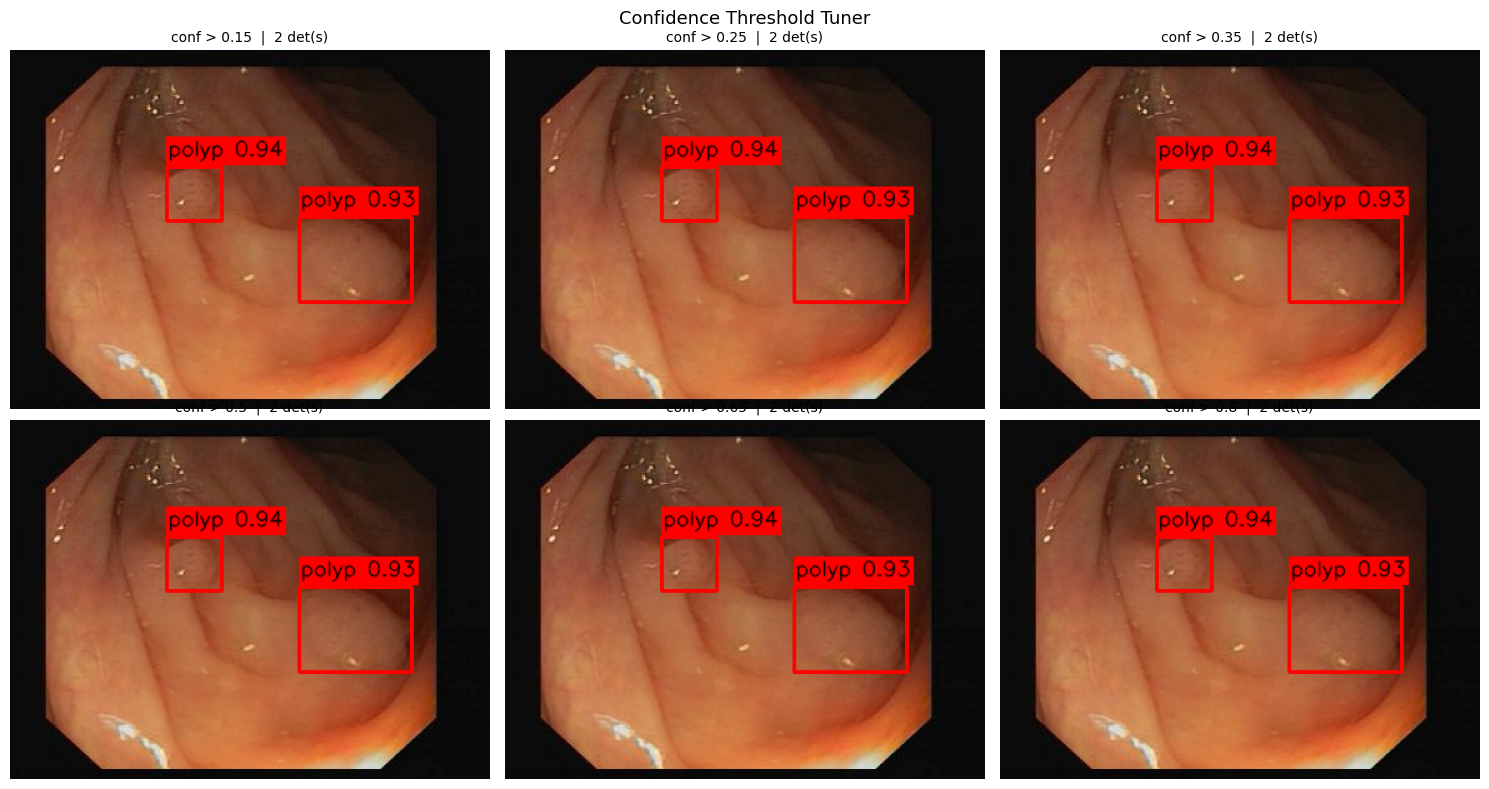

Pick the threshold that gives the best balance of detections vs false positives.


In [6]:
TUNE_IMAGE = IMAGE_PATH
THRESHOLDS = [0.15, 0.25, 0.35, 0.50, 0.65, 0.80]

frame = cv2.imread(TUNE_IMAGE)
if frame is None:
    raise FileNotFoundError(f'Could not read: {TUNE_IMAGE}')

tensor, lb_params = preprocess(frame)
with torch.no_grad():
    output = model(tensor)

cols = 3
rows = math.ceil(len(THRESHOLDS) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
axes = np.array(axes).flatten()

for i, thr in enumerate(THRESHOLDS):
    dets = postprocess(output, lb_params, frame.shape[:2],
                       conf_thresh=thr, iou_thresh=IOU_THRESH)
    ann  = draw_detections(frame, dets)
    axes[i].imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'conf > {thr}  |  {len(dets)} det(s)', fontsize=10)
    axes[i].axis('off')

for ax in axes[len(THRESHOLDS):]:
    ax.set_visible(False)

fig.suptitle('Confidence Threshold Tuner', fontsize=13)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'conf_tuner.png', dpi=150, bbox_inches='tight')
plt.show()
print('Pick the threshold that gives the best balance of detections vs false positives.')